# Analysis Brainstorm

## Ideas of how to quantify bus "performance"

- Stop idle times
- Average bus speed
- Time to complete one full loop

## Compare SPRING 2026 (last semester) with FALL 2026 (this semester)

## Compare Housing Express and South Campus Express performance

## Compare route performance over the course of the day

In [16]:
import glob
import os
import re

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data"
TIMEZONE = "America/Denver"
MAX_GAP_S = 60                  # pings further apart than this aren't treated as consecutive
LOOP_ANCHOR_STOP = "Lundstrum"  # served exactly once per loop on BOTH routes

ROUTE_NAMES = {"housing_express": "Housing Express", "south_campus": "South Campus Express"}

In [ ]:
def load_semester(semester):
    frames = []
    for path in sorted(glob.glob(f"{DATA_DIR}/{semester}/*.csv")):
        m = re.match(r"(housing_express|south_campus)_(\d+-\d+-\d+)\.csv", os.path.basename(path))
        if not m:
            continue
        df = pd.read_csv(path)
        if df.empty:
            print(f"Skipping empty file: {path}")
            continue
        df["route"] = ROUTE_NAMES[m.group(1)]
        df["date"] = pd.to_datetime(m.group(2), format="%m-%d-%y").date()
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    df["time"] = pd.to_datetime(df["timestamp"], unit="s", utc=True).dt.tz_convert(TIMEZONE)
    df = df.sort_values(["route", "date", "vehicle_id", "timestamp"]).reset_index(drop=True)

    # A "run" is an unbroken stretch of recording for one bus. Visits and loops never span two runs,
    # so recording gaps (e.g. 10/2 around 10:20-10:50) can't create fake long idle times or loops.
    grp = df.groupby(["route", "date", "vehicle_id"])
    df["run_id"] = (grp.ngroup().diff().ne(0) | (grp["timestamp"].diff() > MAX_GAP_S)).cumsum()
    return df

df = load_semester("fall26")
df.head()

Skipping empty file: data/fall26\south_campus_9-29-26.csv


,timestamp,vehicle_id,coordinates,stop,distance_along_route,route,date,time,run_id
0,1.790692e+09,17703,"(-111.8043289, 41.7496889)",in_transit,1859.597011,Housing Express,2026-09-29,2026-09-29 08:32:05.672488928-06:00,1
1,1.790692e+09,17703,"(-111.8043102, 41.7505634)",in_transit,1958.247389,Housing Express,2026-09-29,2026-09-29 08:32:15.954719067-06:00,1
2,1.790692e+09,17703,"(-111.8043252, 41.7508111)",Aggie Village 1,1985.780821,Housing Express,2026-09-29,2026-09-29 08:32:26.300385952-06:00,1
3,1.790692e+09,17703,"(-111.8043301, 41.7508153)",Aggie Village 1,1986.256886,Housing Express,2026-09-29,2026-09-29 08:32:36.604615927-06:00,1
4,1.790692e+09,17703,"(-111.8043384, 41.7508296)",Aggie Village 1,1987.861158,Housing Express,2026-09-29,2026-09-29 08:32:46.866716862-06:00,1


In [30]:
df["visit_id"] = ((df["stop"] != df["stop"].shift()) | (df["run_id"] != df["run_id"].shift())).cumsum()

visits = (
    df[df["stop"] != "in_transit"]
      .groupby("visit_id")
      .agg(route=("route", "first"), run_id=("run_id", "first"), stop=("stop", "first"),
           arrive=("time", "first"), depart=("time", "last"), arrive_ts=("timestamp", "first"))
      .reset_index(drop=True)
)
visits["idle_s"] = (visits["depart"] - visits["arrive"]).dt.total_seconds()

print(f"{len(visits)} stop visits")
visits.head()

1373 stop visits


,route,run_id,stop,arrive,depart,arrive_ts,idle_s
0,Housing Express,1,Aggie Village 1,2026-09-29 08:32:26.300385952-06:00,2026-09-29 08:32:46.866716862-06:00,1.790692e+09,20.566331
1,Housing Express,1,Aggie Village 2,2026-09-29 08:33:59.175498962-06:00,2026-09-29 08:34:30.128401994-06:00,1.790692e+09,30.952903
2,Housing Express,1,Aggie Village 3,2026-09-29 08:35:11.367892981-06:00,2026-09-29 08:35:31.967169046-06:00,1.790693e+09,20.599276
3,Housing Express,1,800 E 900 N,2026-09-29 08:37:35.822377920-06:00,2026-09-29 08:38:58.358335018-06:00,1.790693e+09,82.535957
4,Housing Express,1,Field House,2026-09-29 08:41:22.809895992-06:00,2026-09-29 08:42:24.715216875-06:00,1.790693e+09,61.905321


In [31]:
idle_by_stop = (
    visits.groupby(["route", "stop"])["idle_s"]
          .agg(visits="size", median="median", mean="mean", p90=lambda s: s.quantile(0.9), max="max")
          .round(1)
          .sort_values(["route", "median"], ascending=[True, False])
)
idle_by_stop

visits  median  mean    p90  \
route                stop                                                  
Housing Express      Lundstrum                  110    31.0  40.7   61.9   
                     800 E 900 N                111    30.8  34.5   61.8   
                     Field House                109    30.8  46.3   94.5   
                     Aggie Village 2            111    20.5  20.3   31.0   
                     Veterinary Science         110    20.5  21.1   30.9   
                     Aggie Village 3            111    10.4  17.9   30.8   
                     Aggie Village 1            106    10.3  10.9   20.6   
                     Aggie Ice Cream             29     0.0   0.0    0.0   
                     Industrial Science          94     0.0   6.4   20.5   
South Campus Express Taggart Student Center      69    51.3  67.7  154.1   
                     Family Life Bldg            70    30.8  37.4   63.7   
                     Lundstrum                   71    30.8  42.1   71.9   
                     The Bull                    68    20.6  24.8   51.3   
                     670 E 500 N                 69    20.5  17.4   30.8   
                     Fine Arts Bldg              71    10.3  12.4   30.8   
                     Logan Cemetery              64    10.3  10.9   20.6   

                                               max  
route                stop                           
Housing Express      Lundstrum               174.6  
                     800 E 900 N             113.1  
                     Field House             256.8  
                     Aggie Village 2          61.6  
                     Veterinary Science       92.9  
                     Aggie Village 3          92.9  
                     Aggie Village 1          30.9  
                     Aggie Ice Cream           0.0  
                     Industrial Science       41.0  
South Campus Express Taggart Student Center  297.6  
                     Family Life Bldg        102.7  
                     Lundstrum               164.3  
                     The Bull                 71.9  
                     670 E 500 N              61.7  
                     Fine Arts Bldg           41.1  
                     Logan Cemetery           41.1

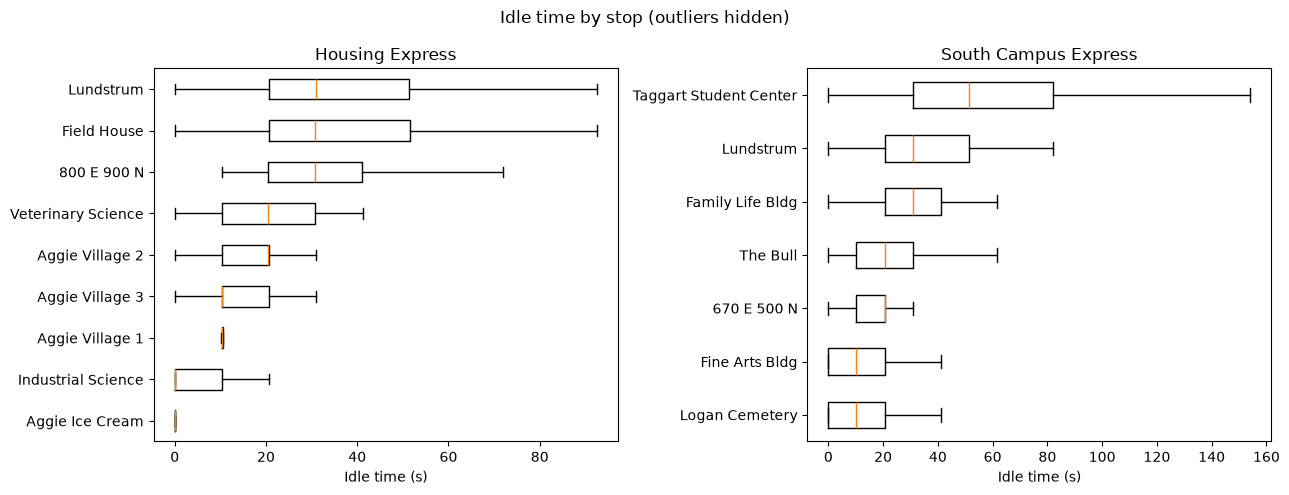

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (route, g) in zip(axes, visits.groupby("route")):
    order = g.groupby("stop")["idle_s"].median().sort_values().index
    ax.boxplot([g.loc[g["stop"] == s, "idle_s"] for s in order], orientation="horizontal", showfliers=False)
    ax.set_yticks(range(1, len(order) + 1), order)
    ax.set_xlabel("Idle time (s)")
    ax.set_title(route)
plt.suptitle("Idle time by stop (outliers hidden)")
plt.tight_layout()
plt.show()

In [25]:
loops = visits[visits["stop"] == LOOP_ANCHOR_STOP].sort_values("arrive_ts").copy()
loops["loop_min"] = loops.groupby("run_id")["arrive_ts"].diff() / 60
loops = loops.dropna(subset=["loop_min"])
loops["hour"] = loops["arrive"].dt.hour

# Flag loops way longer than normal (missed Lundstrum ping or a driver break)
loops["suspect"] = loops["loop_min"] > 1.5 * loops.groupby("route")["loop_min"].transform("median")
print(f"Suspect loops removed: {loops['suspect'].sum()}")

clean_loops = loops[~loops["suspect"]]
clean_loops.groupby("route")["loop_min"].describe().round(2)

Suspect loops removed: 0


,count,mean,std,min,25%,50%,75%,max
route,,,,,,,,
Housing Express,106.0,15.01,2.10,9.93,13.27,15.06,16.26,22.35
South Campus Express,67.0,16.54,2.03,12.49,15.40,16.60,17.29,21.91


In [22]:
hourly_loops = (
    clean_loops.groupby(["route", "hour"])["loop_min"]
               .agg(loops="size", median="median",
                    q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
               .round(2)
)
hourly_loops

loops  median    q25    q75
route                hour                             
Housing Express      7         2   10.78  10.35  11.21
                     8         8   14.56  12.92  15.49
                     9        12   14.67  12.84  16.43
                     10        8   15.78  14.79  16.54
                     11       12   13.90  13.21  15.97
                     12       11   13.24  12.61  14.72
                     13       11   17.11  15.31  17.63
                     14       14   14.55  14.25  15.06
                     15       11   15.24  14.63  15.83
                     16       12   15.49  14.85  16.13
                     17        5   16.09  13.35  16.60
South Campus Express 7         2   13.60  13.31  13.90
                     8         8   15.49  14.77  16.99
                     9         6   17.12  16.82  19.35
                     10        4   17.20  17.11  17.37
                     11        6   16.77  15.84  17.07
                     12        8   15.92  15.53  17.07
                     13        6   18.14  16.52  19.25
                     14        7   17.11  16.69  17.63
                     15        8   15.58  15.06  16.78
                     16        7   15.58  14.98  15.58
                     17        5   15.06  14.55  16.78

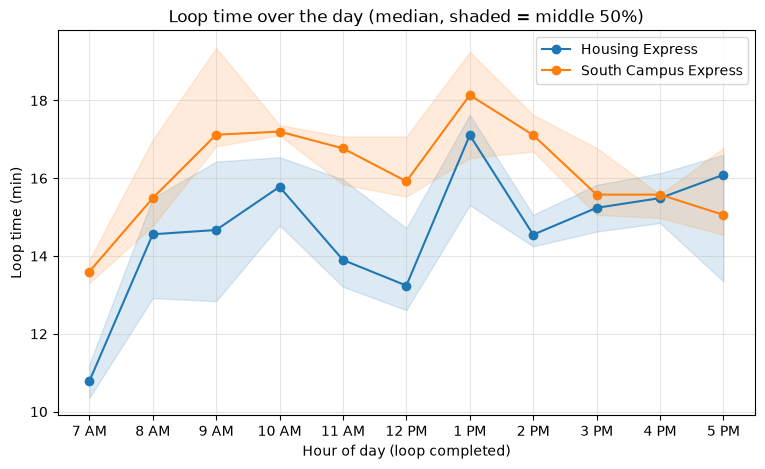

In [28]:
def hour_label(h):
    suffix = "AM" if h < 12 else "PM"
    return f"{(h - 1) % 12 + 1} {suffix}"

hours = range(7, 18)  # 7 AM to 5 PM

fig, ax = plt.subplots(figsize=(9, 5))
for route, g in hourly_loops.reset_index().groupby("route"):
    line, = ax.plot(g["hour"], g["median"], marker="o", label=route)
    ax.fill_between(g["hour"], g["q25"], g["q75"], color=line.get_color(), alpha=0.15)
ax.set_xlabel("Hour of day (loop completed)")
ax.set_ylabel("Loop time (min)")
ax.set_title("Loop time over the day (median, shaded = middle 50%)")
ax.set_xticks(hours, [hour_label(h) for h in hours])
ax.grid(alpha=0.3)
ax.legend()
plt.show()